In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import itertools
from scipy.integrate import ode
from scipy.optimize import minimize 
from tqdm import tqdm
import numpy as np
import scipy

In [20]:
PLASMID_SIZES = {
    "Unsigned": 4966,
    "Signed": 5223,
    "pV18": 7287,
    "pV19": 12027,
    "pV20": 16441}

plasmids = np.array(list(PLASMID_SIZES.keys()))


data = pd.read_csv("Folder1-Flow_Cytometry_Data/20241002-GSIN-Unmixed_Experiment_016-Unmixed.CSV", index_col=0)
cells = data.iloc[:,8]
data = pd.DataFrame(data["GFP+ Cells % Parent"])
def find_plasmid(index_name):
    for plasmid in plasmids:
        if plasmid in index_name:
            return plasmid
    return "Unknown"

# Apply to index and create a new column

data["Plasmid"] = [find_plasmid(idx) for idx in data.index]
data = data[["Unknown" not in x for x in data["Plasmid"]]]
data["Plasmid Size"] = [PLASMID_SIZES[find_plasmid(idx)] for idx in data.index]

# Function to calculate plasmid copies per cell in media
def calculate_plasmid_copies_per_cell(mass_ng, plasmid_bp):
    AVOGADRO = 6.022e23
    bp_weight = 660  # g/mol per bp
    mass_g = mass_ng * 1e-9
    moles = mass_g / (plasmid_bp * bp_weight)
    return (moles * AVOGADRO) / PLATED_CELLS

TOTAL_DNA_NG = 1000
PLATED_CELLS = 2.5e5


data["# Plasmids per cell"] = [calculate_plasmid_copies_per_cell(TOTAL_DNA_NG, x) for x in data.iloc[:,-1]]
data["GFP+"] = data["GFP+ Cells % Parent"]/100
data["Cells"] = cells



In [21]:
## this function is taken from the UQ-Bio 2024 Summer School Github https://github.com/MunskyGroup/uqbio2024

def build_inf_gen(S, W, states, pars, t=0):
    """ Build the infinitesimal generator matrix for a continuous time Markov chain.
    S: Stoichiometry matrix
    W: Propensity vector function
    states: list of states in FSP approximation
    t: time
    """
    
    # Determie the number of species, states and reactions
    nSpecies, nStates = states.shape
    nReactions = S.shape[1]
    
    # Compute the propensity functions for all states.
    propensities = W(states, t, pars)

    # Step through each reaction
    infGens = []
    infGen = np.zeros((nStates+1,nStates+1))
    sink = np.zeros(nStates)
    for mu in range(nReactions):
        # Compute flow of probability out of all states due to reaction mu
        infGens.append(-np.diag(propensities[mu,:]))
        
        for i in range(nStates):
            # Compute the states after the reaction mu
            newState = (states[:,i] + S[:,mu]).reshape(-1,1) 

            # Check if the state is non-negative
            if np.all(newState >= 0):
                # Find the index of the state
                try:
                    j = np.where((states == newState).all(axis=0))[0][0]
                    infGens[mu][j,i] += propensities[mu,i]

                except:
                    sink[i] += propensities[mu,i]
        # Add the current reaction to the infinitesimal generator
        infGen[:nStates,:nStates] += infGens[mu]
    
    # Add the sink as the final row of the infinitesimal generator
    infGen[nStates,:nStates] = sink

    return infGens, sink, infGen

In [22]:
unsigned_data = data[["Unsigned" in x for x in data.index]]
signed_data = data[["Signed" in x for x in data.index]]
pV18_data = data[["pV18" in x for x in data.index]]
pV19_data = data[["pV19" in x for x in data.index]]
pV20_data = data[["pV20" in x for x in data.index]]
pV20_data


,GFP+ Cells % Parent,Plasmid,Plasmid Size,# Plasmids per cell,GFP+,Cells
20241002-GSIN-Unmixed-TubeRack_001-GSIN-A6 pV20-1,16.42,pV20,16441,221987.529329,0.1642,6853
20241002-GSIN-Unmixed-TubeRack_001-GSIN-B6 pV20-2,16.76,pV20,16441,221987.529329,0.1676,6689
20241002-GSIN-Unmixed-TubeRack_001-GSIN-C6 pV20-3,16.97,pV20,16441,221987.529329,0.1697,6760
20241002-GSIN-Unmixed-TubeRack_001-GSIN-D6 pV20-4,23.55,pV20,16441,221987.529329,0.2355,6009


In [9]:
def experiment(x0, params):
    import numpy as np
    import itertools
    from scipy.integrate import ode

    max_plasmids = 8
    S = np.array([[1]])  # Stoichiometry: one plasmid enters

    # Create state space for 0 to max_plasmids plasmids inside
    states = np.array(list(itertools.product(range(max_plasmids + 1),))).T

    # Constant rate of plasmid entry based on initial external plasmid pool
    entry_rate = params[0] * x0

    # Parameter dictionary for generator construction
    pars = {'kcell_entry1': entry_rate}

    # Define transition rates for all states (same rate regardless of current state)
    def W_linear(states, t, pars):
        nStates = states.shape[1]
        W = np.zeros((1, nStates))
        W[0, :] = pars['kcell_entry1']
        return W

    # Construct generator matrix for FSP
    infGens, sink, infGenTotal = build_inf_gen(S, W_linear, states, pars)

    # Initial state: 0 plasmids inside
    x0_state = np.zeros(1, dtype=int)
    idx0 = np.where([(states[:, i] == x0_state).all() for i in range(states.shape[1])])[0]
    P0 = np.zeros(infGenTotal.shape[1])
    P0[idx0] = 1

    # Simulate dynamics over 4 hours
    tspan = np.linspace(0, 4, 100)

    def FSPrhs(t, P): return infGenTotal @ P
    def jac(t, P): return infGenTotal

    solver = ode(FSPrhs, jac=jac).set_integrator('vode', method='bdf')
    solver.set_initial_value(P0)

    P_approach1 = np.zeros((len(tspan), len(P0)))
    P_approach1[0, :] = P0
    for i in range(1, len(tspan)):
        P_approach1[i, :] = solver.integrate(tspan[i])

    # Final state probabilities
    P_final = P_approach1[-1, :]

    # Compute GFP+ probability (i.e., >0 plasmids)
    GFP_positive_prob = np.sum(P_final[:-1][states[0, :] > 0])
    #print(GFP_positive_prob)
    return GFP_positive_prob


In [10]:

def simulate_step(log_target, proposal_width, x):
    """
    Perform one step of the MH algorithm starting at `x`, with a normal distribution
    for the proposal. `log_target` is the logarithm of the target distribution
    and `proposal_width` is the width of the proposal distribution. Returns the next
    sample.
    """
    # propose a new value
    y = x + proposal_width * np.random.randn(len(x))
    if np.any(y < 0) or np.any(y > 1):
        return x  # Reject proposal and return current value
    log_alpha = np.sum(log_target(y) - log_target(x))    # the q-terms cancel
    if log_alpha > 0:
        return y           # accept
    alpha = np.exp(log_alpha)
    p = np.random.rand()
    if p < alpha:        # this happens with probability alpha
        return y           # accept
    else:
        return x           # reject
def metropolis_hastings(log_target, proposal_width, nsteps, x):
    """
    Perform MCMC by running the Metropolis-Hastings algorithm for `nsteps` steps,
    starting at `x0`. `log_target` is the logarithm of the target distribution
    and `proposal_width` is the width of the proposal distribution. Returns a matrix
    of samples.
    """
    ret = np.zeros((nsteps, len(x)))
    ret[0] = x
    for i in tqdm(range(1, nsteps)):
        ret[i] = simulate_step(log_target, proposal_width, ret[i-1])
    return ret

In [11]:
def log_likelihood_transfection(params):
    try:
        total_log_likelihood = 0
        for x0, data_obs, n_cells in zip(x0_list, data_list, n_cells_list):
            pred_prob = experiment(x0, params)
            eps = 1e-8
            pred_prob = np.clip(pred_prob, eps, 1 - eps)
            k_obs = np.round(data_obs * n_cells)  # Observed positive cells
            log_prob = (k_obs * np.log(pred_prob)) + ((n_cells - k_obs) * np.log(1 - pred_prob))
            total_log_likelihood += log_prob
        return total_log_likelihood  # convert NLL to log-likelihood
    except:
        return -np.inf  # return very low likelihood if it crashes
    
    
    
def log_likelihood_transfection(params):
    try:
        total_log_likelihood = 0
        eps = 1e-5

        for x0, data_obs, n_cells in zip(x0_list, data_list, n_cells_list):
            pred_probs = experiment(x0, params)
            pred_probs = np.clip(pred_probs, eps, 1 - eps)
            expected_counts = pred_probs * n_cells
            k_obs = np.round(data_obs * n_cells).astype(int)

            log_prob = scipy.stats.poisson.logpmf(k_obs, expected_counts)
            total_log_likelihood += np.sum(log_prob)

        return total_log_likelihood
    except:
        return -np.inf
    
def log_prior_transfection(params):
    rate = params[0]
    if rate <= 0 or rate > 100:  # adjust based on your prior belief
        return -np.inf
    return np.log(scipy.stats.gamma(a=2, scale=5e-8).pdf(rate))  # weak gamma prior


def log_posterior_transfection(params):
    return log_likelihood_transfection(params) + log_prior_transfection(params)

def objective_func(params):
    total_nll = -log_likelihood_transfection(params)
    return total_nll



In [12]:

res_x = []
res_fun = []
ev = np.inf
df = pV20_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
for i in range(100):
    guess = np.random.random(1) * 1e-6
    fit = minimize(objective_func, guess, tol = 1e-6,  method = 'Nelder-Mead', bounds = [[0, 1]])
    res_x.append(fit.x)
    res_fun.append(fit.fun)
    if fit.fun < ev:
        ev = fit.fun
res_x_pV20 = res_x
res_fun_pV20 = res_fun

In [13]:

res_x = []
res_fun = []
ev = np.inf
df = pV19_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
for i in range(100):
    guess = np.random.random(1) * 1e-6
    fit = minimize(objective_func, guess, tol = 1e-6,  method = 'Nelder-Mead', bounds = [[0, 1]])
    res_x.append(fit.x)
    res_fun.append(fit.fun)
    if fit.fun < ev:
        ev = fit.fun
res_x_pV19 = res_x
res_fun_pV19 = res_fun

In [14]:

res_x = []
res_fun = []
ev = np.inf
df = pV18_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
for i in range(100):
    guess = np.random.random(1) * 1e-6
    fit = minimize(objective_func, guess, tol = 1e-6,  method = 'Nelder-Mead', bounds = [[0, 1]])
    res_x.append(fit.x)
    res_fun.append(fit.fun)
    if fit.fun < ev:
        ev = fit.fun
res_x_pV18 = res_x
res_fun_pV18 = res_fun

In [15]:

res_x = []
res_fun = []
ev = np.inf
df = signed_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
for i in range(100):
    guess = np.random.random(1) * 1e-6
    fit = minimize(objective_func, guess, tol = 1e-6,  method = 'Nelder-Mead', bounds = [[0, 1]])
    res_x.append(fit.x)
    res_fun.append(fit.fun)
    if fit.fun < ev:
        ev = fit.fun
res_x_signed = res_x
res_fun_signed = res_fun

In [16]:

res_x = []
res_fun = []
ev = np.inf
df = unsigned_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
for i in range(100):
    guess = np.random.random(1) * 1e-6
    fit = minimize(objective_func, guess, tol = 1e-6,  method = 'Nelder-Mead', bounds = [[0, 1]])
    res_x.append(fit.x)
    res_fun.append(fit.fun)
    if fit.fun < ev:
        ev = fit.fun
res_x_unsigned = res_x
res_fun_unsigned = res_fun

In [17]:
print(res_x_unsigned[np.where( res_fun_unsigned == np.min(res_fun_unsigned))[0][0]])
print(res_x_signed[np.where( res_fun_signed == np.min(res_fun_signed))[0][0]])
print(res_x_pV18[np.where( res_fun_pV18 == np.min(res_fun_pV18))[0][0]])
print(res_x_pV19[np.where( res_fun_pV19 == np.min(res_fun_pV19))[0][0]])
print(res_x_pV20[np.where( res_fun_pV20 == np.min(res_fun_pV20))[0][0]])


[1.68057739e-07]
[2.18293481e-07]
[2.25461437e-07]
[3.05954877e-07]
[2.27258797e-07]


In [18]:
res_x_pV20 = res_x_pV20[np.where( res_fun_pV20 == np.min(res_fun_pV20))[0][0]]
res_x_pV19 = res_x_pV19[np.where( res_fun_pV19 == np.min(res_fun_pV19))[0][0]]
res_x_pV18 = res_x_pV18[np.where( res_fun_pV18 == np.min(res_fun_pV18))[0][0]]
res_x_signed = res_x_signed[np.where( res_fun_signed == np.min(res_fun_signed))[0][0]]
res_x_unsigned =res_x_unsigned[np.where( res_fun_unsigned == np.min(res_fun_unsigned))[0][0]]

In [19]:
proposal_width = 1e-6

In [20]:

df = pV20_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
nsteps = 102000
samples = metropolis_hastings(log_posterior_transfection, proposal_width, nsteps,  np.array(res_x_pV20) )
burnin = 2000  # discard early samples if needed
posterior_samples = samples[burnin:, 0]  # select the parameter column
lower = np.percentile(posterior_samples, 2.5)
upper = np.percentile(posterior_samples, 97.5)
print(f"95% credible interval: [{lower}, {upper}]")
pV20_lower = lower
pV20_upper = upper

100%|██████████| 101999/101999 [11:24<00:00, 149.11it/s] 

95% credible interval: [2.196431727366544e-07, 2.339368854152433e-07]


In [21]:

df = pV19_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
nsteps = 102000
samples = metropolis_hastings(log_posterior_transfection, proposal_width, nsteps,  np.array(res_x_pV19) )
burnin = 2000  
posterior_samples = samples[burnin:, 0]  
lower = np.percentile(posterior_samples, 2.5)
upper = np.percentile(posterior_samples, 97.5)
print(f"95% credible interval: [{lower}, {upper}]")
pV19_lower = lower
pV19_upper = upper

100%|██████████| 101999/101999 [10:46<00:00, 157.78it/s]

95% credible interval: [2.9642871839109234e-07, 3.1429960484459603e-07]


In [22]:

df = pV18_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
nsteps = 102000
samples = metropolis_hastings(log_posterior_transfection, proposal_width, nsteps,  np.array(res_x_pV18) )
burnin = 2000  
posterior_samples = samples[burnin:, 0]  
lower = np.percentile(posterior_samples, 2.5)
upper = np.percentile(posterior_samples, 97.5)
print(f"95% credible interval: [{lower}, {upper}]")
pV18_lower = lower
pV18_upper = upper

100%|██████████| 101999/101999 [10:31<00:00, 161.46it/s]

95% credible interval: [2.2039613104788381e-07, 2.3233824086555822e-07]


In [23]:

df = signed_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
nsteps = 102000
samples = metropolis_hastings(log_posterior_transfection, proposal_width, nsteps,  np.array(res_x_signed) )
burnin = 2000  # discard early samples if needed
posterior_samples = samples[burnin:, 0]  # select the parameter column
lower = np.percentile(posterior_samples, 2.5)
upper = np.percentile(posterior_samples, 97.5)
print(f"95% credible interval: [{lower}, {upper}]")
signed_lower = lower
signed_upper = upper

100%|██████████| 101999/101999 [10:31<00:00, 161.53it/s]

95% credible interval: [2.120547877845651e-07, 2.2318218523610935e-07]


In [24]:

df = unsigned_data
x0_list = np.array(df.iloc[:,-3])
data_list = np.array(df.iloc[:,-2])
n_cells_list = df.iloc[:,-1]
nsteps = 102000
samples = metropolis_hastings(log_posterior_transfection, proposal_width, nsteps,  np.array(res_x_unsigned) )
burnin = 2000  # discard early samples if needed
posterior_samples = samples[burnin:, 0]  # select the parameter column
lower = np.percentile(posterior_samples, 2.5)
upper = np.percentile(posterior_samples, 97.5)
print(f"95% credible interval: [{lower}, {upper}]")
unsigned_lower = lower
unsigned_upper = upper

100%|██████████| 101999/101999 [07:38<00:00, 222.60it/s]

95% credible interval: [1.635894972350865e-07, 1.724975295104778e-07]


In [25]:
estimates = np.array([
    res_x_unsigned,
    res_x_signed,
    res_x_pV18,
    res_x_pV19,
    res_x_pV20
]).flatten()


uppers = np.array([
    unsigned_upper,
    signed_upper,
    pV18_upper,
    pV19_upper,
    pV20_upper]).flatten()


lowers = np.array([
    unsigned_lower,
    signed_lower,
    pV18_lower,
    pV19_lower,
    pV20_lower]).flatten()

LL = np.array([
    np.min(res_fun_unsigned),
    np.min(res_fun_signed),
    np.min(res_fun_pV18),
    np.min(res_fun_pV19),
    np.min(res_fun_pV20)]).flatten()

In [5]:
fits = pd.concat([pd.DataFrame([plasmids]), pd.DataFrame([lowers]), pd.DataFrame([estimates]), pd.DataFrame([uppers]), pd.DataFrame([LL]) ]).T
fits.columns = ["Plasmid", "95% CI Lower Bound", "Estimate", "95% CI Upper Bound", "Estimate Log Likelihood"]
fits.to_csv("Folder2-Model_Parameter_Fits/fitting_output.csv")



NameError: name 'lowers' is not defined

In [29]:
fits = pd.read_csv("Folder2-Model_Parameter_Fits/fitting_output.csv", index_col = 0)
fits.iloc[:,0] = ["CMV-GFP-Unsigned", "CMV-GFP-Signed", "pV18", "pV19", "pV20"]
fits.Plasmid

0    CMV-GFP-Unsigned
1      CMV-GFP-Signed
2                pV18
3                pV19
4                pV20
Name: Plasmid, dtype: object

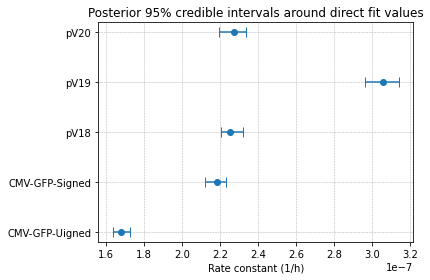

In [15]:


# Direct fits (point estimates)
means = fits.iloc[:, 2]

# 95% credible intervals (from MCMC)
lowers = fits.iloc[:, 1]
uppers = fits.iloc[:, 3]

# Labels
plasmids = fits.iloc[:, 0]

# Error bars (asymmetric)
errors = [
    [mean - lower for mean, lower in zip(means, lowers)],
    [upper - mean for upper, mean in zip(uppers, means)]
]

# Plot
plt.errorbar(means, plasmids, xerr=errors, fmt='o', capsize=5)
#plt.xscale('log')
plt.xlabel("Rate constant (1/h)")
plt.title("Posterior 95% credible intervals around direct fit values")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


In [16]:
def experiment_pred(x0, params):

    max_plasmids = 8
    S = np.array([[1]])  # Stoichiometry: one plasmid enters

    # Create state space for 0 to max_plasmids plasmids inside
    states = np.array(list(itertools.product(range(max_plasmids + 1),))).T

    # Constant rate of plasmid entry based on initial external plasmid pool
    entry_rate = params[0] * x0

    # Parameter dictionary for generator construction
    pars = {'kcell_entry1': entry_rate}

    # Define transition rates for all states (same rate regardless of current state)
    def W_linear(states, t, pars):
        nStates = states.shape[1]
        W = np.zeros((1, nStates))
        W[0, :] = pars['kcell_entry1']
        return W

    # Construct generator matrix for FSP
    infGens, sink, infGenTotal = build_inf_gen(S, W_linear, states, pars)

    # Initial state: 0 plasmids inside
    x0_state = np.zeros(1, dtype=int)
    idx0 = np.where([(states[:, i] == x0_state).all() for i in range(states.shape[1])])[0]
    P0 = np.zeros(infGenTotal.shape[1])
    P0[idx0] = 1

    # Simulate dynamics over 4 hours
    tspan = np.linspace(0, 4, 100)

    def FSPrhs(t, P): return infGenTotal @ P
    def jac(t, P): return infGenTotal

    solver = ode(FSPrhs, jac=jac).set_integrator('vode', method='bdf')
    solver.set_initial_value(P0)

    P_approach1 = np.zeros((len(tspan), len(P0)))
    P_approach1[0, :] = P0
    for i in range(1, len(tspan)):
        P_approach1[i, :] = solver.integrate(tspan[i])

    # Final state probabilities
    P_final = P_approach1[-1, :]

    # Compute GFP+ probability (i.e., >0 plasmids)
    GFP_positive_prob = np.sum(P_final[:-1][states[0, :] > 0])

    return GFP_positive_prob


In [23]:

x0 = signed_data.iloc[:,-3][0]
params = [fits.iloc[:, 2][1]]
signed_pred = experiment_pred(x0, params)

x0 = unsigned_data.iloc[:,-3][0]
params = [fits.iloc[:, 2][0]]
unsigned_pred = experiment_pred(x0, params)

x0 = pV18_data.iloc[:,-3][0]
params = [fits.iloc[:, 2][2]]
pV18_pred = experiment_pred(x0, params)

x0 = pV19_data.iloc[:,-3][0]
params = [fits.iloc[:, 2][3]]
pV19_pred = experiment_pred(x0, params)

x0 = pV20_data.iloc[:,-3][0]
params = [fits.iloc[:, 2][4]]
pV20_pred = experiment_pred(x0, params)

In [24]:
data_plot = [unsigned_data.iloc[:,0],
signed_data.iloc[:,0],
pV18_data.iloc[:,0],
pV19_data.iloc[:,0],
pV20_data.iloc[:,0]]


data_plot_mn = [np.mean(unsigned_data.iloc[:,0]),
np.mean(signed_data.iloc[:,0]),
np.mean(pV18_data.iloc[:,0]),
np.mean(pV19_data.iloc[:,0]),
np.mean(pV20_data.iloc[:,0])]

data_plot_len = np.array([len(unsigned_data.iloc[:,0]),
len(signed_data.iloc[:,0]),
len(pV18_data.iloc[:,0]),
len(pV19_data.iloc[:,0]),
len(pV20_data.iloc[:,0])])

data_plot_sd = np.array([np.std(unsigned_data.iloc[:,0]),
np.std(signed_data.iloc[:,0]),
np.std(pV18_data.iloc[:,0]),
np.std(pV19_data.iloc[:,0]),
np.std(pV20_data.iloc[:,0])]) * 2
data_plot_se = data_plot_sd/np.sqrt(data_plot_len)

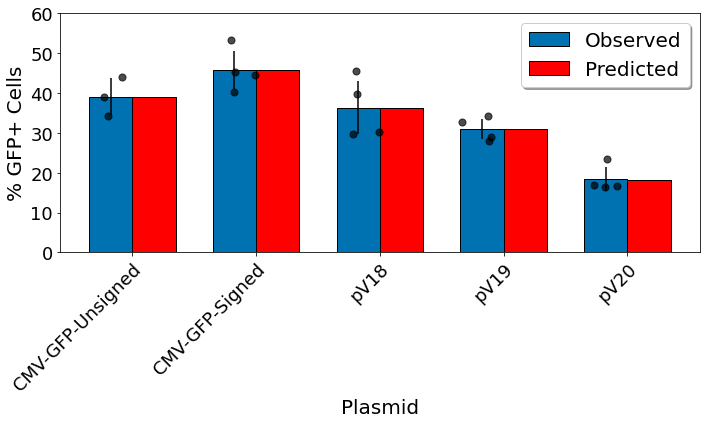

In [32]:
categories = fits.Plasmid
indices = np.arange(len(categories))
indices
fig, ax = plt.subplots(figsize=(10, 6))
# Create bars
bar_width = 0.35

ax.bar(indices - bar_width/2, data_plot_mn, width=bar_width, yerr= data_plot_se, color='#0072B2', edgecolor='black', label='Observed')


preds = np.array([unsigned_pred,
signed_pred,
pV18_pred,
pV19_pred,
pV20_pred])

for i, d in enumerate(data_plot):
    # Scatter each point slightly spread out horizontally (for visibility)
    x_jitter = np.random.normal(loc=indices[i] - bar_width/2, scale=0.08, size=len(d))
    ax.scatter(x_jitter, d, color='black', alpha=0.7, s=50, zorder=10)

ax.tick_params(axis='y', labelsize=18)
ax.bar(indices + bar_width/2, preds*100, width=bar_width, color='red', edgecolor='black', label='Predicted')


ax.legend(loc='best', fontsize=20, frameon=True, shadow=True)
# Set labels, title, and ticks
ax.set_xticks(indices)
plt.ylim([0,60])
ax.set_xticklabels(categories, fontsize=18,rotation=45, ha='right', rotation_mode='anchor')
ax.set_ylabel('% GFP+ Cells', fontsize=20)
ax.set_xlabel('Plasmid', fontsize=20)
plt.tight_layout()
plt.savefig(f"Figures/Fig3/plasmid_datavpreds.svg")
plt.show()   


In [35]:
def log_likelihood_transfection(params):
    try:
        total_log_likelihood = 0
        datasets = [unsigned_data, signed_data, pV18_data, pV19_data, pV20_data]

        for df in datasets:
            x0_list = df.iloc[:, -3].to_numpy()
            data_obs_list = df.iloc[:, -2].to_numpy()
            n_cells_list = df.iloc[:, -1].to_numpy()

            for x0, data_obs, n_cells in zip(x0_list, data_obs_list, n_cells_list):
                pred_prob = experiment(x0, params)
                eps = 1e-8
                pred_prob = np.clip(pred_prob, eps, 1 - eps)
                k_obs = np.round(data_obs * n_cells)  # Observed number of positive cells
                log_prob = (k_obs * np.log(pred_prob)) + ((n_cells - k_obs) * np.log(1 - pred_prob))
                total_log_likelihood += log_prob

        return total_log_likelihood  # ***no minus here***
    except Exception:
        return -np.inf

def log_likelihood_transfection(params):
    try:
        total_log_likelihood = 0
        datasets = [unsigned_data, signed_data, pV18_data, pV19_data, pV20_data]
        eps = 1e-5

        for df in datasets:
            x0_list = df.iloc[:, -3].to_numpy()
            data_obs_list = df.iloc[:, -2].to_numpy()
            n_cells_list = df.iloc[:, -1].to_numpy()

            for x0, data_obs, n_cells in zip(x0_list, data_obs_list, n_cells_list):
                pred_prob = experiment(x0, params)
                pred_prob = np.clip(pred_prob, eps, 1 - eps)
                
                expected_count = pred_prob * n_cells
                k_obs = int(round(data_obs * n_cells))

                log_prob = scipy.stats.poisson.logpmf(k_obs, expected_count)
                total_log_likelihood += log_prob

        return total_log_likelihood
    except Exception:
        return -np.inf
    
    

def log_prior_transfection(params):
    rate = params[0]
    if rate <= 0 or rate > 100:
        return -np.inf
    return np.log(scipy.stats.gamma(a=2, scale=5e-8).pdf(rate))

def log_posterior_transfection(params):
    return log_likelihood_transfection(params) + log_prior_transfection(params)

def objective_func(params):
    return -log_likelihood_transfection(params)  # ***minus sign here for optimization***




In [36]:

res_x = []
res_fun = []
ev = np.inf

for i in range(100):
    guess = np.random.random(1) * 1e-6
    fit = minimize(objective_func, guess, tol = 1e-6,  method = 'Nelder-Mead', bounds = [[0, 1]])
    res_x.append(fit.x)
    res_fun.append(fit.fun)
    if fit.fun < ev:
        ev = fit.fun
res_x_all = res_x
res_fun_all = res_fun

In [37]:
print(res_x_all[np.where( res_fun_all == np.min(res_fun_all))[0][0]])
res_x_all=res_x_all[np.where( res_fun_all == np.min(res_fun_all))[0][0]]

[2.26650429e-07]


In [38]:
nsteps = 102000
samples = metropolis_hastings(log_posterior_transfection, proposal_width, nsteps,  np.array(res_x_all) )
burnin = 2000  
posterior_samples = samples[burnin:, 0]  
lower = np.percentile(posterior_samples, 2.5)
upper = np.percentile(posterior_samples, 97.5)
print(f"95% credible interval: [{lower}, {upper}]")
all_lower = lower
all_upper = upper

100%|██████████| 101999/101999 [1:45:07<00:00, 16.17it/s]   

95% credible interval: [2.239934936262851e-07, 2.2894470608402692e-07]


In [39]:
fits = pd.DataFrame(["All", all_lower, res_x_all[0], all_upper, np.min(res_fun_all)]).T
fits.columns = ["Plasmid", "95% CI Lower Bound", "Estimate", "95% CI Upper Bound", "Estimate Log Likelihood"]
fits.to_csv("Folder2-Model_Parameter_Fits/all_fit_output.csv")
fits


,Plasmid,95% CI Lower Bound,Estimate,95% CI Upper Bound,Estimate Log Likelihood
0,All,0.0,0.0,0.0,857.01299
